# Let's build a MLP step-by-step!

> Goals:
> - Understand the structure of a MLP (and implement)
> - Understand activation functions of neural networks
> - Gain an introduction to loss functions
> - Gain an introduction to the learning process

In [1]:
! pip install torchvision

In [2]:
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=transform
)

X_train = train_dataset.data.numpy().astype(np.float32) / 255.0
y_train = train_dataset.targets.numpy()

X_test = test_dataset.data.numpy().astype(np.float32) / 255.0
y_test = test_dataset.targets.numpy()

X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

In [3]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(60000, 784), dtype=float32)

In [4]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,))

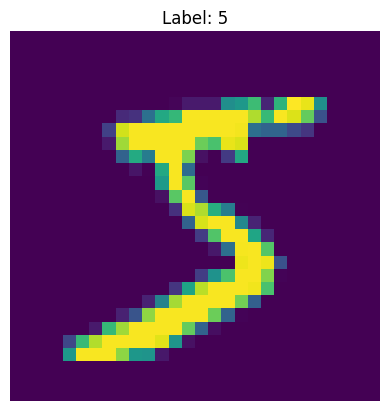

In [5]:
def show_image(i):
    # reshape back to image
    image = X_train[i].reshape(28, 28)
    label = y_train[i]

    plt.figure()
    plt.imshow(image)
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()
    
show_image(0)

## Node Class
- Given some input $x\in \mathbb{R}^n$
- Use the weights $w\in \mathbb{R}^n$ and bias $b\in \mathbb{R}$ to get an output

## Layer Class
- We have single neurons/nodes implemented
- We want to stack them with some dimension $dim$
- How do we define a forward pass for an input through $dim$ neurons in a layer

## MLP Class
- Stack layers horizontally to form a complete network
- What we have to define?
    - List of the dimensions of each layer

In [167]:
from autograd import Value

class Neuron:
    def __init__(self, weights:list, bias:Value=0):
        self.weights = weights
        self.bias = bias
        self.n = len(weights)
        
    def forward(self, x:list):
        ## w^Tx + b
        output = 0
        for i in range(self.n):
            output += self.weights[i] * x[i]
            
        output += self.bias
        return output
    
    def parameters(self):
        return self.weights + [self.bias]

In [168]:
x = [Value(1.0), Value(0.0), Value(2.0)]
n1 = Neuron([Value(1.0), Value(1.0), Value(1.0)], Value(5))

## [1,1,1]^T[1,0,2] + 5 = 8
n1.forward(x)

:8.0

In [169]:
import numpy as np
class Layer:
    def __init__(self, dim_in:int, dim_out:int):
        self.dim_out = dim_out
        self.dim_in = dim_in
        
        self.neurons = []
        
        ## layer represented as a list of neurons
        ## weights are N(0,1)
        for i in range(dim_out):
            self.neurons += [Neuron([Value(np.random.normal(0, 1) * 0.01) for _ in range(dim_in)], Value(0.0))]
                        
    def forward(self, x:list, nonlinearity=None):
        output = []
        
        ## w^Tx + b
        ## now imagine x is still a vector, but W is a matrix and b a vector
        ## W has dimension [dim_in, dim_out]
        
        for i in range(self.dim_out):
            neuron = self.neurons[i]
            output += [neuron.forward(x)]
            
        # print("Before relu:", output)
            
        if nonlinearity:
            for i in range(len(output)):
                output[i] = output[i].relu()
            
        return output
    

    def parameters(self):
        output = []
        
        for i in range(self.dim_out):
            output += [self.neurons[i].parameters()]
            
        return output
            

In [170]:
x = [Value(1.0), Value(0.0), Value(2.0)]
L1 = Layer(3, 4)

L1.forward(x, Value.relu)

[:0.03695623663401036,
 :0.02592562592489506,
 :0.01942956413738704,
 :0.03201578316989957]

In [171]:
L1.parameters()

[[:0.00952480149885597, :0.009580011070816583, :0.013715717567577196, :0.0],
 [:0.005119944125969945, :-0.016169779048983767, :0.010402840899462558, :0.0],
 [:-0.001246559612657631, :0.013338907950972216, :0.010338061875022335, :0.0],
 [:-0.0020605973097587876, :0.0014256482543022317, :0.01703819023982918, :0.0]]

For MNIST, out initial vectors have dimension 784, and our output has dimension 10

We want a network with 2 hidden layers of dimension [100, 500]

In [172]:
class MLP:
    def __init__(self, dim_in, layer_sizes:list, dim_out, non_linearities:list):
        self.layer_sizes = layer_sizes
        self.layers = []
        self.non_linearities = non_linearities
        
        total_dimensions = [dim_in] + layer_sizes + [dim_out]
        
        for i in range(len(total_dimensions) - 1):
            self.layers += [Layer(total_dimensions[i], total_dimensions[i+1])]
                            
    def forward(self, x:list):
        cur_x = x
        for i in range(len(self.layer_sizes)):
            cur_x = self.layers[i].forward(cur_x, self.non_linearities[i])
            
        output = self.layers[-1].forward(cur_x)
                            
        return output
    
    def parameters(self):
        output = []
        for layer in self.layers:
            output += [layer.parameters()]
            
        return output

In [173]:
x_value = [Value(cur) for cur in X_train[0]]

mlp = MLP(784, [100, 50], 10, [Value.relu, Value.relu])
out = mlp.forward(x_value)

In [174]:
out

[:-0.00044590479228645563,
 :0.0007267019827850163,
 :-1.4656288840342313e-05,
 :0.0001462378422729671,
 :-0.00016730200150050223,
 :0.0006328493473120034,
 :0.0006507736397907138,
 :-0.0006159163312986493,
 :0.0004922125372104347,
 :-0.00017671784735284746]

In [175]:
## Value of first layer's first neuron's first weight
mlp.parameters()[0][0][0]

:-0.005869385397450182

In [176]:
## Gradient of first layer's first neuron's first weight
mlp.parameters()[0][0][0].grad

0

## Some major issues

- Values don't sum to 1
    - Softmax function
- This is fully linear
    - No non-linearity in this network, expressive power of a linear classifier

## Softmax

Goal: arbitrary weights -> distribution
- Useful for classification (like MNIST) up to next-token prediction

$$softmax(x)_i = \frac{e^{x_i}}{\sum_i e^{x_i}}$$

$$x_{max} = max_i(e^{x_i})$$

For numerical stability, $$softmax(x)_i = \frac{e^{x_i} - x_{max}}{\sum_i e^{x_i - x_{max}}}$$


In [177]:
def softmax(x:list):
    x_max = float('-inf')
    for i in range(len(x)):
        x_max = max(x_max, x[i].data)
        
    print(x_max)
    x_max = Value(x_max)
    
    output = []
    denom = 0
    print(x)
    for i in range(len(x)):
        cur = (x[i] - x_max).exp()
        output += [cur]
        denom += cur
        
    for i in range(len(output)):
        output[i] = output[i] / denom
                
    return output

In [178]:
probs = softmax(out)

0.000726702
[:-0.00044590479228645563, :0.0007267019827850163, :-1.4656288840342313e-05, :0.0001462378422729671, :-0.00016730200150050223, :0.0006328493473120034, :0.0006507736397907138, :-0.0006159163312986493, :0.0004922125372104347, :-0.00017671784735284746]


In [179]:
probs

[:0.09994313239851305,
 :0.10006039513661043,
 :0.09998624202614875,
 :0.10000233051919263,
 :0.09997098071615766,
 :0.10005100464548845,
 :0.10005279800503081,
 :0.09992614235705274,
 :0.10003693478074129,
 :0.09997003941506416]

__Initially, our network makes random guesses__

In [180]:
total = 0
for i in range(len(probs)):
    total += probs[i]
    
total

:1.0

## Define our loss function

$$\mathcal{L}_{CE}(P_{pred}, P_{target}) = - \sum_i P_{target}[i] * \log P_{pred}[i]$$

In [181]:
def cross_entropy_loss(p_target, p_pred):
    loss = Value(0.0)
    for i in range(len(p_target)):
        loss -= p_target[i] * (p_pred[i]).log()
        
    return loss

In [182]:
target = [Value(0.0) for _ in range(10)]
target[4] = Value(1.0)
loss = cross_entropy_loss(target, probs)
loss

:2.3028753279465586

In [183]:
from autograd import backward
backward(loss)

In [184]:
loss.grad

1

In [185]:
mlp.parameters()[-1][3][40].data

-0.004924729684326559

In [186]:
mlp.parameters()[-1][3][40].grad

np.float32(0.00058032334)

__As get to shallower layers, gradients approach 0__

In [187]:
mlp.parameters()[0][3][3].grad

np.float32(0.0)

## Gradient descent

Assume we've backpropagated through out network WRT loss
- Iterate over each parameter
- Gather its gradient
- Move that parameter in the negative direction of $\alpha *$ grad where $\alpha$ is a learning rate

In [188]:
def flatten_params(params):
    flat = []

    for p in params:
        if isinstance(p, list):
            flat.extend(flatten_params(p))
        else:
            flat.append(p)

    return flat

def gradient_descent(model: MLP, lr: float):
    for param in flatten_params(model.parameters()):
        param.data -= lr * param.grad
        
gradient_descent(mlp, 1e-3)

In [189]:
mlp.parameters()[-1][3][40].data

np.float32(-0.0049253097)

In [165]:
## previously: -0.004924729684326559

In [190]:
gradient_descent(mlp, 1)
mlp.parameters()[-1][3][40].data

np.float32(-0.005505633)

## We trained the weights a little bit on this example, let's produce another output

In [203]:
out = mlp.forward(x_value)

In [204]:
probs = softmax(out)

0.9056859
[:-0.10127011686563492, :-0.09980757534503937, :-0.10058806091547012, :-0.10163124650716782, :0.9056859016418457, :-0.10057001560926437, :-0.09938454627990723, :-0.10143130272626877, :-0.10039449483156204, :-0.1003345251083374]


In [205]:
loss = cross_entropy_loss(target, probs)
loss

:1.4563251096854872

In [195]:
## Previously loss was 2.3028753279465586

In [202]:
backward(loss)
gradient_descent(mlp, 1e-3)